In [1]:
import sys
sys.path.append('../')
from utils_jax import *
import optax
dq.set_device('cpu')
import warnings
warnings.filterwarnings("ignore")

In [2]:
n_lvls_fluxonium = 25
n_lvls_transmon = 4


Ej_f = 3
Ec_f = 3/4
El_f = 3/20.5

qsf = qs.Fluxonium.create(
    n_lvls_fluxonium,
    {"Ej": Ej_f, "Ec": Ec_f, "El": El_f, "phi_ext": 0.0},
    N_pre_diag=100,
    use_linear = False
    )


def get_element(Ej_t):

    Ec_t = 0.2
    g_tf = 0.1
    
    qst = MyTransmon.create(
        N = n_lvls_transmon,
        params = {"Ej": Ej_t, "Ec": Ec_t,"ng":0.0},
        N_max_charge=8
        )

    devices = [qsf, qst]
    f_indx = 0
    t_indx = 1
    Ns = [device.N for device in devices]
    fn = qs.promote(qsf.ops["n"], f_indx, Ns)
    tn = qs.promote(qst.ops['n'], t_indx, Ns)

    system = qs.System.create(devices, couplings=[
        g_tf *  fn @ tn
        ])
    system.params["g_tf"] = g_tf
    system_evals_sorted, system_evecs_sorted, product_indices_sorted_by_eval = calculate_eig(Ns, system.get_H())
    driven_op = transform_op_into_dressed_basis_jax(fn, system_evecs_sorted.T)


    matrix_element_0001 = driven_op[
        find_closest_dressed_index( 0*n_lvls_transmon + 0, product_indices_sorted_by_eval),
        find_closest_dressed_index( 0*n_lvls_transmon + 1, product_indices_sorted_by_eval)
    ]
    matrix_element_1011 = driven_op[
        find_closest_dressed_index( 1*n_lvls_transmon + 0, product_indices_sorted_by_eval),
        find_closest_dressed_index( 1*n_lvls_transmon + 1, product_indices_sorted_by_eval)
    ]
    matrix_element_2021 = driven_op[
        find_closest_dressed_index( 2*n_lvls_transmon + 0, product_indices_sorted_by_eval),
        find_closest_dressed_index( 2*n_lvls_transmon + 1, product_indices_sorted_by_eval)
    ]
    return matrix_element_0001, matrix_element_1011, matrix_element_2021


get_element_jitted = jax.jit(get_element)

In [6]:
from tqdm import tqdm
import numpy as np
Ej_array = np.linspace(2,15,1000).tolist()
zero_ele = []
one_ele = []
two_ele = []
for Ej in tqdm(Ej_array,desc='sweeping'):
    matrix_element_0001, matrix_element_1011, matrix_element_2021 = get_element(Ej)
    zero_ele.append(matrix_element_0001)
    one_ele.append(matrix_element_1011)
    two_ele.append(matrix_element_2021)

sweeping: 100%|██████████| 1000/1000 [11:01<00:00,  1.51it/s]


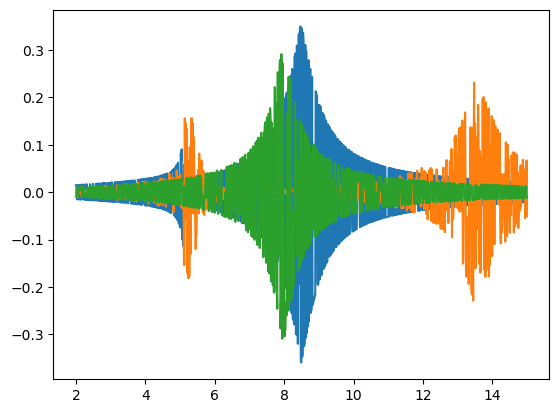

In [9]:
import matplotlib.pyplot as plt
plt.plot(Ej_array,zero_ele)
plt.plot(Ej_array,one_ele)
plt.plot(Ej_array,two_ele)